In [1]:
# Run once if needed:
# %pip install numpy pandas scipy statsmodels matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower, TTestIndPower
from statsmodels.stats.multitest import multipletests

rng = np.random.default_rng(42)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
n_a = 5_000
n_b = 5_000

ab = pd.DataFrame({
    "variant": np.repeat(["A", "B"], [n_a, n_b])
})

# True conversion rates used only to generate the demo data
conversion_prob = np.where(ab["variant"] == "A", 0.100, 0.115)
ab["converted"] = rng.binomial(1, conversion_prob)

# Revenue is zero for non-converters and variable for converters
order_value = rng.lognormal(
    mean=np.where(ab["variant"] == "A", 4.00, 4.04),
    sigma=0.55
)

ab["revenue"] = ab["converted"] * order_value

ab.head()

,variant,converted,revenue
0,A,0,0.0000
1,A,0,0.0000
2,A,0,0.0000
3,A,0,0.0000
4,A,0,0.0000


In [3]:
ab.groupby("variant").agg(
    users=("variant", "size"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean"),
    total_revenue=("revenue", "sum"),
    revenue_per_user=("revenue", "mean"),
    avg_order_value=("revenue", lambda x: x[x > 0].mean())
)

,users,conversions,conversion_rate,total_revenue,revenue_per_user,avg_order_value
variant,,,,,,
A,5000,493,0.0986,"32,866.0630",6.5732,66.6654
B,5000,559,0.1118,"38,416.7651",7.6834,68.7241


In [4]:
summary = ab.groupby("variant")["converted"].agg(["sum", "count", "mean"])

conversions = summary["sum"].to_numpy()
sample_sizes = summary["count"].to_numpy()

z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=sample_sizes,
    alternative="two-sided"
)

rate_a = summary.loc["A", "mean"]
rate_b = summary.loc["B", "mean"]

absolute_lift = rate_b - rate_a
relative_lift = rate_b / rate_a - 1

print(f"A conversion rate: {rate_a:.2%}")
print(f"B conversion rate: {rate_b:.2%}")
print(f"Absolute lift:       {absolute_lift:.2%}")
print(f"Relative lift:       {relative_lift:.2%}")
print(f"Z statistic:         {z_stat:.3f}")
print(f"P-value:             {p_value:.4f}")

A conversion rate: 9.86%
B conversion rate: 11.18%
Absolute lift:       1.32%
Relative lift:       13.39%
Z statistic:         -2.151
P-value:             0.0315


In [5]:
def proportion_difference_ci(success_a, n_a, success_b, n_b, confidence=0.95):
    p_a = success_a / n_a
    p_b = success_b / n_b

    difference = p_b - p_a

    standard_error = np.sqrt(
        p_a * (1 - p_a) / n_a +
        p_b * (1 - p_b) / n_b
    )

    critical_value = stats.norm.ppf(1 - (1 - confidence) / 2)

    lower = difference - critical_value * standard_error
    upper = difference + critical_value * standard_error

    return difference, lower, upper


success_a = summary.loc["A", "sum"]
success_b = summary.loc["B", "sum"]
n_a = summary.loc["A", "count"]
n_b = summary.loc["B", "count"]

difference, ci_low, ci_high = proportion_difference_ci(
    success_a, n_a, success_b, n_b
)

print(f"Estimated absolute lift: {difference:.2%}")
print(f"95% CI: [{ci_low:.2%}, {ci_high:.2%}]")

Estimated absolute lift: 1.32%
95% CI: [0.12%, 2.52%]


In [6]:
alpha = 0.05
minimum_useful_lift = 0.005  # 0.5 percentage points

if p_value < alpha and ci_low > minimum_useful_lift:
    conclusion = "B is statistically significant and likely practically useful."
elif p_value < alpha and ci_high < -minimum_useful_lift:
    conclusion = "B is statistically significantly worse."
elif p_value < alpha:
    conclusion = "A difference is detectable, but its business value is uncertain."
elif ci_low <= 0 <= ci_high:
    conclusion = "The experiment is inconclusive. Both improvement and harm remain plausible."
else:
    conclusion = "No statistically significant difference was detected."

print(conclusion)

A difference is detectable, but its business value is uncertain.


In [7]:
revenue_a = ab.loc[ab["variant"] == "A", "revenue"]
revenue_b = ab.loc[ab["variant"] == "B", "revenue"]

t_stat, p_value_revenue = stats.ttest_ind(
    revenue_b,
    revenue_a,
    equal_var=False
)

mean_a = revenue_a.mean()
mean_b = revenue_b.mean()
difference = mean_b - mean_a
relative_difference = mean_b / mean_a - 1

print(f"A revenue per user: ${mean_a:,.2f}")
print(f"B revenue per user: ${mean_b:,.2f}")
print(f"Difference:         ${difference:,.2f}")
print(f"Relative lift:       {relative_difference:.2%}")
print(f"T statistic:         {t_stat:.3f}")
print(f"P-value:             {p_value_revenue:.4f}")

A revenue per user: $6.57
B revenue per user: $7.68
Difference:         $1.11
Relative lift:       16.89%
T statistic:         2.200
P-value:             0.0279


In [8]:
def welch_mean_difference_ci(a, b, confidence=0.95):
    """
    Returns B - A and a Welch confidence interval.
    """
    a = np.asarray(a)
    b = np.asarray(b)

    mean_difference = b.mean() - a.mean()

    var_a = a.var(ddof=1)
    var_b = b.var(ddof=1)
    n_a = len(a)
    n_b = len(b)

    se = np.sqrt(var_a / n_a + var_b / n_b)

    degrees_freedom = (
        (var_a / n_a + var_b / n_b) ** 2
        / (
            (var_a / n_a) ** 2 / (n_a - 1)
            + (var_b / n_b) ** 2 / (n_b - 1)
        )
    )

    critical_value = stats.t.ppf(
        1 - (1 - confidence) / 2,
        df=degrees_freedom
    )

    lower = mean_difference - critical_value * se
    upper = mean_difference + critical_value * se

    return mean_difference, lower, upper, degrees_freedom


difference, lower, upper, df = welch_mean_difference_ci(
    revenue_a,
    revenue_b
)

print(f"Difference in revenue per user: ${difference:,.2f}")
print(f"95% CI: [${lower:,.2f}, ${upper:,.2f}]")
print(f"Welch degrees of freedom: {df:,.1f}")

Difference in revenue per user: $1.11
95% CI: [$0.12, $2.10]
Welch degrees of freedom: 9,986.5


In [9]:
def bootstrap_mean_difference(a, b, n_bootstrap=10_000, confidence=0.95, seed=42):
    rng = np.random.default_rng(seed)

    a = np.asarray(a)
    b = np.asarray(b)

    bootstrap_differences = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample_a = rng.choice(a, size=len(a), replace=True)
        sample_b = rng.choice(b, size=len(b), replace=True)

        bootstrap_differences[i] = sample_b.mean() - sample_a.mean()

    alpha = 1 - confidence
    lower, upper = np.quantile(
        bootstrap_differences,
        [alpha / 2, 1 - alpha / 2]
    )

    return {
        "observed_difference": b.mean() - a.mean(),
        "ci_low": lower,
        "ci_high": upper,
        "bootstrap_distribution": bootstrap_differences
    }


bootstrap_result = bootstrap_mean_difference(
    revenue_a,
    revenue_b
)

print(
    f"Observed difference: "
    f"${bootstrap_result['observed_difference']:,.2f}"
)
print(
    f"Bootstrap 95% CI: "
    f"[${bootstrap_result['ci_low']:,.2f}, "
    f"${bootstrap_result['ci_high']:,.2f}]"
)

Observed difference: $1.11
Bootstrap 95% CI: [$0.14, $2.11]


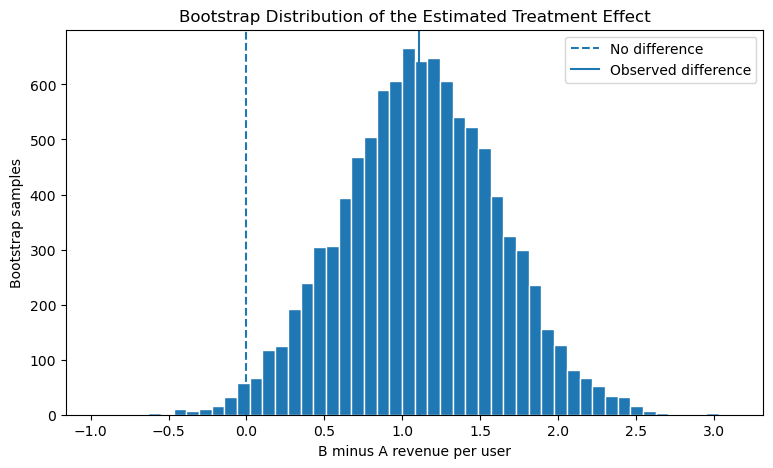

In [10]:
plt.figure(figsize=(9, 5))

plt.hist(
    bootstrap_result["bootstrap_distribution"],
    bins=50,
    edgecolor="white"
)

plt.axvline(0, linestyle="--", label="No difference")
plt.axvline(
    bootstrap_result["observed_difference"],
    linestyle="-",
    label="Observed difference"
)

plt.xlabel("B minus A revenue per user")
plt.ylabel("Bootstrap samples")
plt.title("Bootstrap Distribution of the Estimated Treatment Effect")
plt.legend()
plt.show()